# Momentum-Driven Sector Rotation in Indian Equities

### Author: Sai Ashwin Nagulapati

This project investigates a momentum and trend-following strategy on the NIFTY 50 universe using 63-day momentum, EMA50 trend filters, and quarterly rebalancing.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
stocks = [
    "ADANIENT.NS",
    "ADANIPORTS.NS",
    "APOLLOHOSP.NS",
    "ASIANPAINT.NS",
    "AXISBANK.NS",
    "BAJAJ-AUTO.NS",
    "BAJFINANCE.NS",
    "BEL.NS",
    "BHARTIARTL.NS",
    "CIPLA.NS",
    "COALINDIA.NS",
    "DRREDDY.NS",
    "EICHERMOT.NS",
    "ETERNAL.NS",   # formerly Zomato
    "GRASIM.NS",
    "HCLTECH.NS",
    "HDFCBANK.NS",
    "HDFCLIFE.NS",
    "HEROMOTOCO.NS",
    "HINDALCO.NS",
    "HINDUNILVR.NS",
    "ICICIBANK.NS",
    "INDUSINDBK.NS",
    "INFY.NS",
    "ITC.NS",
    "JIOFIN.NS",
    "JSWSTEEL.NS",
    "KOTAKBANK.NS",
    "LT.NS",
    "M&M.NS",
    "MARUTI.NS",
    "NESTLEIND.NS",
    "NTPC.NS",
    "ONGC.NS",
    "POWERGRID.NS",
    "RELIANCE.NS",
    "SBILIFE.NS",
    "SBIN.NS",
    "SHRIRAMFIN.NS",
    "SUNPHARMA.NS",
    "TATACONSUM.NS",
    "TATAMOTORS.NS",
    "TATASTEEL.NS",
    "TCS.NS",
    "TECHM.NS",
    "TITAN.NS",
    "TRENT.NS",
    "ULTRACEMCO.NS",
    "WIPRO.NS"
]




In [3]:
data = yf.download(
    stocks,
    start="2020-01-01",
    auto_adjust=True,
    progress=False
)["Close"]



HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


In [4]:
nifty = yf.download(
    "^NSEI",
    start=data.index.min(),
    end=data.index.max(),
    auto_adjust=True,
    progress=False
)["Close"]

nifty_returns = nifty.pct_change()


# 2. Signal Construction

Momentum and trend signals are constructed using:

- 63-day momentum
- 50-day EMA
- EMA slope

Look-ahead bias is avoided by shifting signals by one day.

In [5]:
momentum = data.pct_change(63).shift(1)

ema50 = (
   data
    .ewm(span=50, adjust=False)
    .mean()
    .shift(1)
)

price_yesterday = data.shift(1)


ema_slope = ema50.pct_change(10)

# 3. Portfolio Construction

Stocks are ranked by momentum.

Only stocks satisfying the trend filters are eligible.

The portfolio consists of the top 5 momentum stocks with equal weights.

# 4. Backtest Implementation

The strategy is backtested using quarterly rebalancing.

Transaction costs are included and returns are aggregated to create the portfolio equity curve.

In [6]:
rebalance_dates = momentum.index[63::63]

portfolio_returns = []
all_holdings = []
portfolio_history = {}
stock_contributions = {}

transaction_cost = 0.0005



for i in range(len(rebalance_dates) - 1):

    current_date = rebalance_dates[i]
    next_date = rebalance_dates[i + 1]

    if current_date not in momentum.index:
        continue

    mom = momentum.loc[current_date]

    trend_filter = (
        (price_yesterday.loc[current_date] > ema50.loc[current_date])
        &
        (ema_slope.loc[current_date] > 0)
    )

    eligible = mom[trend_filter].dropna()

    if len(eligible) < 5:
        continue

    top5 = eligible.nlargest(5).index

    # Store portfolio
    portfolio_history[current_date] = eligible.nlargest(5)

    # Store holdings
    all_holdings.extend(top5)

    current_loc = data.index.get_loc(current_date)

    if current_loc + 1 >= len(data.index):
        break

    entry_date = data.index[current_loc + 1]

    period_prices = data.loc[
        entry_date:next_date,
        top5
    ]

    # ============================================================
    # STOCK CONTRIBUTION TRACKING
    # ============================================================

    stock_returns = (
        period_prices.iloc[-1]
        /
        period_prices.iloc[0]
        - 1
    )

    for stock in top5:

        if stock not in stock_contributions:
            stock_contributions[stock] = []

        stock_contributions[stock].append(
            stock_returns[stock]
        )

    # ============================================================
    # EQUAL WEIGHT PORTFOLIO RETURNS
    # ============================================================

    period_returns = (
        period_prices
        .pct_change()
        .mean(axis=1)
        .dropna()
    )

    if len(period_returns) > 0:
        period_returns.iloc[0] -= transaction_cost

    portfolio_returns.append(period_returns)

portfolio_returns = pd.concat(portfolio_returns)

portfolio_returns = portfolio_returns[
    ~portfolio_returns.index.duplicated()
]

portfolio_returns = portfolio_returns.dropna()

portfolio_returns.name = "Strategy"

# ============================================================
# LATEST PORTFOLIO
# ============================================================

last_date = list(portfolio_history.keys())[-1]

print("=" * 60)
print("LATEST PORTFOLIO")
print("=" * 60)
print("Rebalance Date:", last_date.date())
print()
print(portfolio_history[last_date])

print()

print("=" * 60)
print("TRANSACTION COST")
print("=" * 60)

print(f"Cost per rebalance: {transaction_cost:.2%}")
print(f"Number of rebalances: {len(portfolio_history)}")
print(f"Approx total cost paid: {transaction_cost * len(portfolio_history):.2%}")

print()

print("=" * 60)
print("STOCKS TRACKED")
print("=" * 60)
print(len(stock_contributions))

LATEST PORTFOLIO
Rebalance Date: 2026-02-06

Ticker
SHRIRAMFIN.NS    0.259363
HINDALCO.NS      0.186517
TECHM.NS         0.164544
INDUSINDBK.NS    0.163063
COALINDIA.NS     0.157309
Name: 2026-02-06 00:00:00, dtype: float64

TRANSACTION COST
Cost per rebalance: 0.05%
Number of rebalances: 23
Approx total cost paid: 1.15%

STOCKS TRACKED
43


In [7]:
# ============================================================
# PORTFOLIO CHANGES
# ============================================================

dates = sorted(portfolio_history.keys())

current_date = dates[-1]
previous_date = dates[-2]

current_portfolio = set(
    portfolio_history[current_date].index
)

previous_portfolio = set(
    portfolio_history[previous_date].index
)

added = current_portfolio - previous_portfolio
removed = previous_portfolio - current_portfolio

print("=" * 60)
print("PORTFOLIO CHANGES")
print("=" * 60)

print(f"Previous Rebalance: {previous_date.date()}")
print(f"Current Rebalance : {current_date.date()}")

print("\nADDED")
print("-" * 20)

for stock in sorted(added):
    print(stock)

print("\nREMOVED")
print("-" * 20)

for stock in sorted(removed):
    print(stock)

print("\nUNCHANGED")
print("-" * 20)

for stock in sorted(
    current_portfolio.intersection(previous_portfolio)
):
    print(stock)

PORTFOLIO CHANGES
Previous Rebalance: 2025-11-07
Current Rebalance : 2026-02-06

ADDED
--------------------
COALINDIA.NS
INDUSINDBK.NS
TECHM.NS

REMOVED
--------------------
BAJFINANCE.NS
EICHERMOT.NS
SBIN.NS

UNCHANGED
--------------------
HINDALCO.NS
SHRIRAMFIN.NS


In [8]:
from collections import Counter

holdings_count = Counter(all_holdings)

print("=" * 60)
print("MOST FREQUENTLY HELD STOCKS")
print("=" * 60)

for stock, count in holdings_count.most_common(15):
    print(f"{stock:<15} {count}")

MOST FREQUENTLY HELD STOCKS
ADANIENT.NS     7
TRENT.NS        6
M&M.NS          5
HINDALCO.NS     5
JSWSTEEL.NS     5
TECHM.NS        5
SHRIRAMFIN.NS   5
BEL.NS          5
HEROMOTOCO.NS   4
TATASTEEL.NS    4
COALINDIA.NS    4
ETERNAL.NS      4
HCLTECH.NS      3
BAJFINANCE.NS   3
ADANIPORTS.NS   3


In [9]:
print("=" * 60)
print("PORTFOLIO DIVERSITY")
print("=" * 60)

print("Unique Stocks Held:", len(set(all_holdings)))
print("Total Stock Selections:", len(all_holdings))

PORTFOLIO DIVERSITY
Unique Stocks Held: 43
Total Stock Selections: 115


In [10]:
# ============================================================
# STOCK CONTRIBUTION ANALYSIS
# ============================================================

contrib_df = pd.DataFrame({
    "Average Return": {
        stock: np.mean(returns)
        for stock, returns
        in stock_contributions.items()
    },
    "Times Held": {
        stock: len(returns)
        for stock, returns
        in stock_contributions.items()
    },
    "Total Return": {
        stock: np.sum(returns)
        for stock, returns
        in stock_contributions.items()
    }
})

contrib_df = contrib_df.sort_values(
    "Total Return",
    ascending=False
)

print("=" * 60)
print("TOP 15 CONTRIBUTORS")
print("=" * 60)

print(
    contrib_df.head(15)
)

print()

print("=" * 60)
print("WORST 15 CONTRIBUTORS")
print("=" * 60)

print(
    contrib_df.tail(15)
)

TOP 15 CONTRIBUTORS
               Average Return  Times Held  Total Return
ADANIENT.NS          0.358127           7      2.506889
TRENT.NS             0.328593           6      1.971560
ETERNAL.NS           0.221057           4      0.884227
JSWSTEEL.NS          0.103065           5      0.515324
SHRIRAMFIN.NS        0.100604           5      0.503022
M&M.NS               0.100310           5      0.501552
ITC.NS               0.163968           3      0.491905
HINDALCO.NS          0.082648           5      0.413240
COALINDIA.NS         0.097761           4      0.391042
TATASTEEL.NS         0.094720           4      0.378881
BAJAJ-AUTO.NS        0.168282           2      0.336565
HEROMOTOCO.NS        0.077336           4      0.309342
NTPC.NS              0.141750           2      0.283500
SBIN.NS              0.086233           3      0.258698
RELIANCE.NS          0.230367           1      0.230367

WORST 15 CONTRIBUTORS
               Average Return  Times Held  Total Return
INDUS

# 5. Performance Evaluation

The strategy is compared against:

- Equal Weight Benchmark
- NIFTY 50 Index

Key metrics include CAGR, Sharpe Ratio, and Maximum Drawdown.

In [11]:
equity_curve = (
    1 + portfolio_returns
).cumprod()

benchmark_returns = (
    data
    .pct_change()
    .mean(axis=1)
)

common_dates = (
    portfolio_returns.index
    .intersection(benchmark_returns.index)
    .intersection(nifty_returns.index)
)

portfolio_returns = portfolio_returns.loc[common_dates]
benchmark_returns = benchmark_returns.loc[common_dates]
nifty_returns = nifty_returns.loc[common_dates]

equity_curve = (
    1 + portfolio_returns
).cumprod()

benchmark_curve = (
    1 + benchmark_returns
).cumprod()

nifty_curve = (
    1 + nifty_returns
).cumprod()

# 6. Equity Curve Analysis

This section visualizes the growth of ₹1 invested in the strategy and compares it against benchmarks.

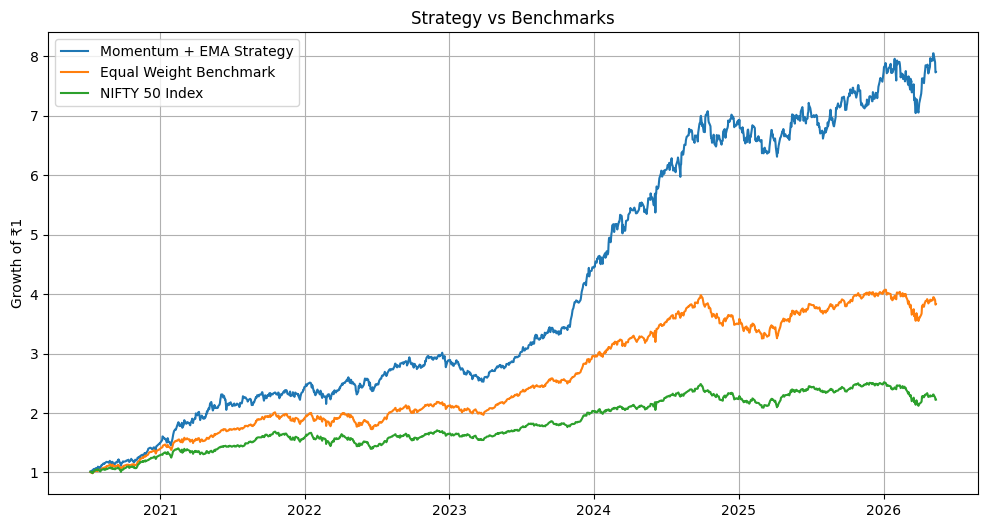

In [12]:
plt.figure(figsize=(12,6))

plt.plot(
    equity_curve,
    label="Momentum + EMA Strategy"
)

plt.plot(
    benchmark_curve,
    label="Equal Weight Benchmark"
)

plt.plot(
    nifty_curve,
    label="NIFTY 50 Index"
)

plt.title("Strategy vs Benchmarks")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.grid(True)




plt.savefig(
    "plots/equity_curve.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()    

# 7. Annual Performance Analysis

Yearly returns are compared against both benchmarks to identify periods of strong and weak performance.

In [13]:
benchmark_annual = (
    benchmark_returns
    .groupby(benchmark_returns.index.year)
    .apply(lambda x: (1+x).prod()-1)
)

nifty_annual = (
    nifty_returns
    .groupby(nifty_returns.index.year)
    .apply(lambda x: (1+x).prod()-1)
)

annual_returns = (
    portfolio_returns
    .groupby(portfolio_returns.index.year)
    .apply(lambda x: (1+x).prod()-1)
)

# Convert everything to numpy arrays
strategy_vals = annual_returns.to_numpy().flatten()
benchmark_vals = benchmark_annual.to_numpy().flatten()
nifty_vals = nifty_annual.to_numpy().flatten()

results = pd.DataFrame({
    "Strategy": strategy_vals,
    "Equal Weight": benchmark_vals,
    "NIFTY50": nifty_vals,
    "Alpha vs EW": strategy_vals - benchmark_vals,
    "Alpha vs NIFTY": strategy_vals - nifty_vals
},
index=annual_returns.index)

results.to_csv(
    "results/yearly_performance.csv"
)

print("\n📊 YEARLY PERFORMANCE COMPARISON")
print(results.map(lambda x: f"{x:.2%}"))


📊 YEARLY PERFORMANCE COMPARISON
     Strategy Equal Weight  NIFTY50 Alpha vs EW Alpha vs NIFTY
Date                                                          
2020   48.48%       39.06%   28.82%       9.43%         19.66%
2021   64.13%       37.43%   23.03%      26.70%         41.10%
2022   18.47%       10.79%    3.77%       7.68%         14.70%
2023   53.95%       39.63%   23.52%      14.32%         30.43%
2024   54.36%       18.26%    9.96%      36.10%         44.40%
2025   12.08%       15.66%   11.84%      -3.58%          0.24%
2026    0.56%       -5.24%  -11.00%       5.79%         11.56%


<Figure size 1200x600 with 0 Axes>

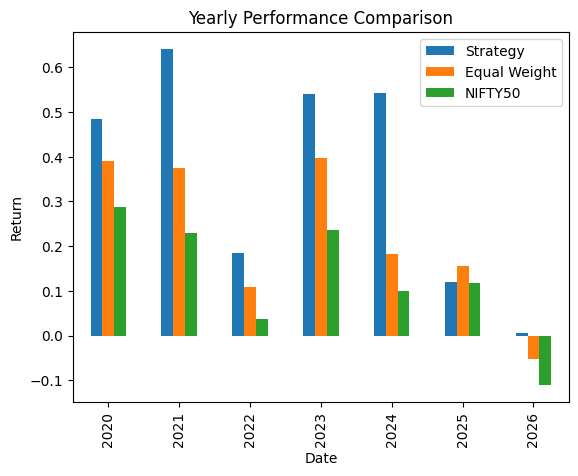

In [14]:
plt.figure(figsize=(12,6))

results[["Strategy","Equal Weight","NIFTY50"]].plot(
    kind="bar"
)

plt.title("Yearly Performance Comparison")
plt.ylabel("Return")

plt.savefig(
    "plots/yearly_returns.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

# 8. Drawdown Analysis

Drawdowns are analyzed to understand the magnitude and duration of portfolio losses.

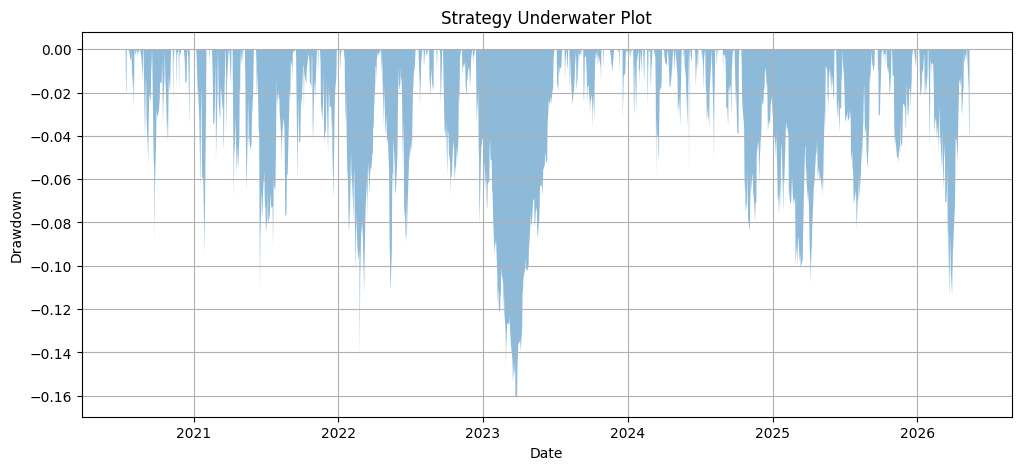

In [15]:
# Calculate drawdown

running_max = equity_curve.cummax()

drawdown = (
    equity_curve
    /
    running_max
    - 1
)

# Plot

plt.figure(figsize=(12, 5))

plt.fill_between(
    drawdown.index,
    drawdown,
    0,
    alpha=0.5
)

plt.title("Strategy Underwater Plot")
plt.ylabel("Drawdown")
plt.xlabel("Date")

plt.grid(True)

plt.savefig(
    "plots/drawdown.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [16]:
print("=" * 60)
print("WORST DRAWDOWN")
print("=" * 60)

print(
    f"Date: {drawdown.idxmin().date()}"
)

print(
    f"Drawdown: {drawdown.min():.2%}"
)

drawdown_days = (
    drawdown < 0
).astype(int)



print("=" * 60)
print("DRAWDOWN STATISTICS")
print("=" * 60)

print(
    f"Average Drawdown: {drawdown.mean():.2%}"
)

print(
    f"Worst Drawdown: {drawdown.min():.2%}"
)

print(
    f"Percent of Time in Drawdown: "
    f"{100 * drawdown_days.mean():.1f}%"
)


WORST DRAWDOWN
Date: 2023-03-28
Drawdown: -16.16%
DRAWDOWN STATISTICS
Average Drawdown: -3.19%
Worst Drawdown: -16.16%
Percent of Time in Drawdown: 82.4%


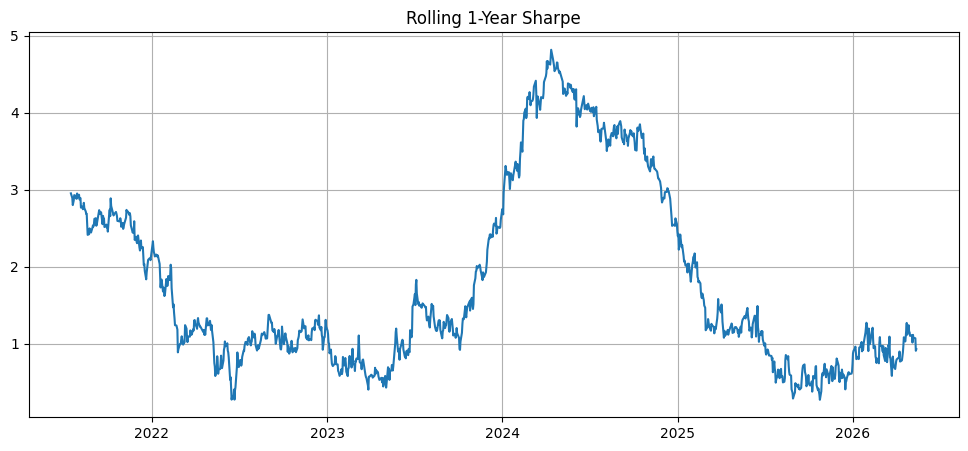

In [17]:
rolling_sharpe = (
    portfolio_returns.rolling(252).mean()
    /
    portfolio_returns.rolling(252).std()
) * np.sqrt(252)

plt.figure(figsize=(12,5))
plt.plot(rolling_sharpe)
plt.title("Rolling 1-Year Sharpe")
plt.grid(True)
plt.show()

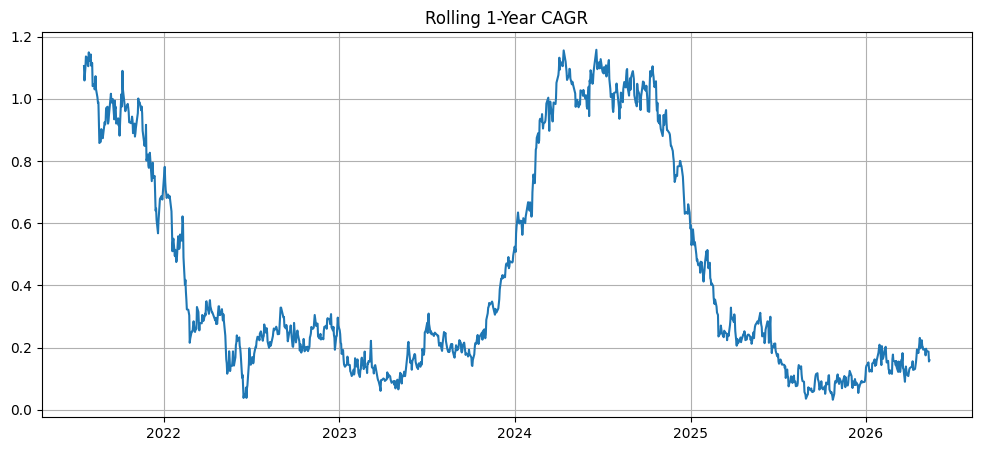

In [18]:
rolling_cagr = (
    equity_curve
    /
    equity_curve.shift(252)
) ** (252 / 252) - 1

plt.figure(figsize=(12,5))
plt.plot(rolling_cagr)

plt.title("Rolling 1-Year CAGR")
plt.grid(True)

plt.show()

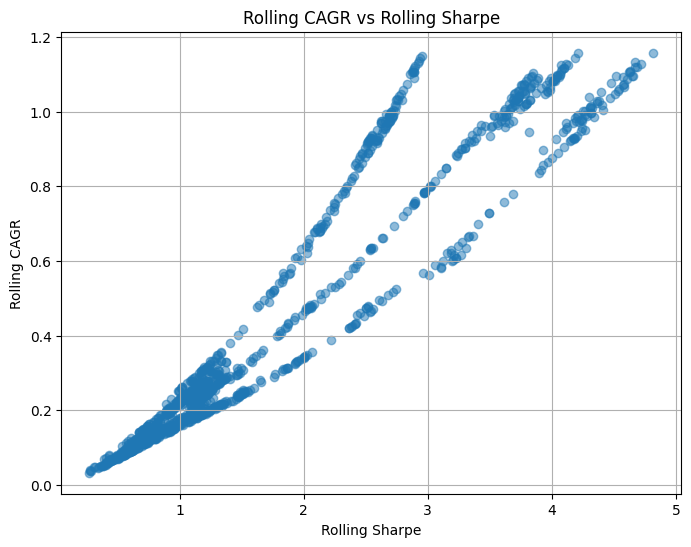

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    rolling_sharpe,
    rolling_cagr,
    alpha=0.5
)

plt.xlabel("Rolling Sharpe")
plt.ylabel("Rolling CAGR")
plt.title("Rolling CAGR vs Rolling Sharpe")

plt.grid(True)

plt.savefig(
    "plots/rolling_cagr_vs_sharpe.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

# 9. Turnover Analysis

Portfolio turnover is measured to evaluate trading activity and implementation costs.

In [20]:
# ============================================================
# TURNOVER ANALYSIS
# ============================================================

dates = sorted(portfolio_history.keys())

turnover_list = []

print("=" * 60)
print("TURNOVER AT EACH REBALANCE")
print("=" * 60)

for i in range(1, len(dates)):

    prev_date = dates[i - 1]
    curr_date = dates[i]

    prev_portfolio = set(
        portfolio_history[prev_date].index
    )

    curr_portfolio = set(
        portfolio_history[curr_date].index
    )

    # Stocks added and removed
    added = curr_portfolio - prev_portfolio
    removed = prev_portfolio - curr_portfolio

    # Total turnover
    turnover = (
        len(added) 
    ) / len(curr_portfolio)

    turnover_list.append(turnover)

    print(
        f"{curr_date.date()} | "
        f"Added: {len(added)} | "
        f"Removed: {len(removed)} | "
        f"Turnover: {turnover:.2%}"
    )

# ============================================================
# SUMMARY STATISTICS
# ============================================================

avg_turnover = np.mean(turnover_list)
max_turnover = np.max(turnover_list)
min_turnover = np.min(turnover_list)

print()
print("=" * 60)
print("TURNOVER SUMMARY")
print("=" * 60)

print(f"Average Turnover : {avg_turnover:.2%}")
print(f"Maximum Turnover : {max_turnover:.2%}")
print(f"Minimum Turnover : {min_turnover:.2%}")

print()
print(
    "Estimated Annual Turnover:",
    f"{avg_turnover * 4:.2%}"
)

TURNOVER AT EACH REBALANCE
2020-10-05 | Added: 5 | Removed: 5 | Turnover: 100.00%
2021-01-04 | Added: 4 | Removed: 4 | Turnover: 80.00%
2021-04-07 | Added: 4 | Removed: 4 | Turnover: 80.00%
2021-07-08 | Added: 4 | Removed: 4 | Turnover: 80.00%
2021-10-08 | Added: 5 | Removed: 5 | Turnover: 100.00%
2022-01-10 | Added: 4 | Removed: 4 | Turnover: 80.00%
2022-04-12 | Added: 4 | Removed: 4 | Turnover: 80.00%
2022-07-13 | Added: 4 | Removed: 4 | Turnover: 80.00%
2022-10-14 | Added: 5 | Removed: 5 | Turnover: 100.00%
2023-01-13 | Added: 5 | Removed: 5 | Turnover: 100.00%
2023-04-20 | Added: 4 | Removed: 4 | Turnover: 80.00%
2023-07-20 | Added: 5 | Removed: 5 | Turnover: 100.00%
2023-10-20 | Added: 4 | Removed: 4 | Turnover: 80.00%
2024-01-24 | Added: 4 | Removed: 4 | Turnover: 80.00%
2024-04-30 | Added: 4 | Removed: 4 | Turnover: 80.00%
2024-08-01 | Added: 3 | Removed: 3 | Turnover: 60.00%
2024-10-31 | Added: 5 | Removed: 5 | Turnover: 100.00%
2025-01-31 | Added: 4 | Removed: 4 | Turnover: 80

In [21]:
survival_rates = []

for i in range(1, len(dates)):

    prev_portfolio = set(
        portfolio_history[dates[i-1]].index
    )

    curr_portfolio = set(
        portfolio_history[dates[i]].index
    )

    survivors = len(
        prev_portfolio.intersection(curr_portfolio)
    )

    survival_rates.append(survivors)

print("Average Survivors:",
      round(np.mean(survival_rates), 2),
      "out of 5")

Average Survivors: 0.68 out of 5


In [22]:

print(
    "Strategy Return:",
    round(
        (equity_curve.iloc[-1]-1)*100,
        2
    ),
    "%"
)

print(
    "Benchmark Return:",
    round(
        (benchmark_curve.iloc[-1]-1)*100,
        2
    ),
    "%"
)


print(
    "NIFTY 50 Return:",
    round(
        (nifty_curve.iloc[-1,0]-1)*100,
        2
    ),
    "%"
)


years = (
    equity_curve.index[-1]
    -
    equity_curve.index[0]
).days / 365.25

cagr = (
    equity_curve.iloc[-1]
    ** (1 / years)
    - 1
)

print(f"CAGR: {cagr:.2%}")

sharpe = (
    portfolio_returns.mean()
    /
    portfolio_returns.std()
) * np.sqrt(252)

print(f"Sharpe: {sharpe:.2f}")

running_max = equity_curve.cummax()

drawdown = (
    equity_curve
    /
    running_max
    - 1
)

max_dd = drawdown.min()

print(f"Max Drawdown: {max_dd:.2%}")

Strategy Return: 673.23 %
Benchmark Return: 283.16 %
NIFTY 50 Return: 122.35 %
CAGR: 41.92%
Sharpe: 1.86
Max Drawdown: -16.16%


In [23]:
summary = pd.DataFrame({

    "Metric": [
        "Strategy Return",
        "Benchmark Return",
        "NIFTY Return",
        "CAGR",
        "Sharpe",
        "Max Drawdown"
    ],

    "Value": [
        portfolio_returns,
        benchmark_curve,
        nifty_curve,
        cagr,
        sharpe,
        max_dd
    ]
})

summary.to_csv(
    "results/summary_metrics.csv",
    index=False
)

In [24]:
# ============================================================
# LIVE PORTFOLIO RECOMMENDATION
# ============================================================

latest_date = momentum.index[-1]

mom = momentum.loc[latest_date]

trend_filter = (
    (price_yesterday.loc[latest_date] > ema50.loc[latest_date])
    &
    (ema_slope.loc[latest_date] > 0)
)

eligible = mom[trend_filter].dropna()

top5 = eligible.nlargest(5)
watchlist = eligible.nlargest(10)

print("=" * 60)
print("PORTFOLIO TO BUY TODAY")
print("=" * 60)
print("Signal Date:", latest_date.date())
print()

portfolio_df = pd.DataFrame({
    "Momentum Score": top5.round(4),
    "Suggested Weight": "20%"
})

print(portfolio_df)

print()
print("=" * 60)
print("TOP 10 MOMENTUM CANDIDATES")
print("=" * 60)
print(watchlist.round(4))

print()
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Stocks Passing Filters: {len(eligible)}")
print(f"Portfolio Size: {len(top5)}")
print("Rebalance Frequency: Every 63 Trading Days (~3 Months)")

PORTFOLIO TO BUY TODAY
Signal Date: 2026-06-24

               Momentum Score Suggested Weight
Ticker                                        
ADANIENT.NS            0.5382              20%
TRENT.NS               0.3264              20%
ADANIPORTS.NS          0.3121              20%
LT.NS                  0.2287              20%
ASIANPAINT.NS          0.2227              20%

TOP 10 MOMENTUM CANDIDATES
Ticker
ADANIENT.NS      0.5382
TRENT.NS         0.3264
ADANIPORTS.NS    0.3121
LT.NS            0.2287
ASIANPAINT.NS    0.2227
GRASIM.NS        0.2018
NESTLEIND.NS     0.1664
BAJFINANCE.NS    0.1588
APOLLOHOSP.NS    0.1525
CIPLA.NS         0.1513
Name: 2026-06-24 00:00:00, dtype: float64

SUMMARY
Stocks Passing Filters: 24
Portfolio Size: 5
Rebalance Frequency: Every 63 Trading Days (~3 Months)


In [25]:
sector_map = {

    # Financials
    "HDFCBANK.NS": "Financials",
    "ICICIBANK.NS": "Financials",
    "AXISBANK.NS": "Financials",
    "KOTAKBANK.NS": "Financials",
    "SBIN.NS": "Financials",
    "BAJFINANCE.NS": "Financials",
    "SHRIRAMFIN.NS": "Financials",

    # IT
    "INFY.NS": "IT",
    "TCS.NS": "IT",
    "WIPRO.NS": "IT",
    "TECHM.NS": "IT",
    "HCLTECH.NS": "IT",

    # FMCG
    "ITC.NS": "FMCG",
    "HINDUNILVR.NS": "FMCG",
    "NESTLEIND.NS": "FMCG",
    "TATACONSUM.NS": "FMCG",

    # Auto
    "M&M.NS": "Auto",
    "MARUTI.NS": "Auto",
    "HEROMOTOCO.NS": "Auto",
    "BAJAJ-AUTO.NS": "Auto",

    # Metals
    "JSWSTEEL.NS": "Metals",
    "TATASTEEL.NS": "Metals",
    "HINDALCO.NS": "Metals",

    # Energy / PSU
    "COALINDIA.NS": "Energy",
    "NTPC.NS": "Energy",
    "RELIANCE.NS": "Energy",

    # Industrials
    "ADANIENT.NS": "Industrials",
    "TRENT.NS": "Retail",
    "ETERNAL.NS": "Retail",

    # Defence
    "BEL.NS": "Defence",

    # Pharma
    "SUNPHARMA.NS": "Pharma",

    # Telecom
    "BHARTIARTL.NS": "Telecom",

    # Others
    "JIOFIN.NS": "Financials",
    "INDUSINDBK.NS": "Financials",
    "GRASIM.NS": "Materials"
}



# 10. Portfolio Attribution

The contribution of individual stocks to total portfolio performance is analyzed.

This helps identify the primary drivers of alpha.

In [26]:
contrib_df["Sector"] = (
    contrib_df.index
    .map(sector_map)
    .fillna("Other")
)

contrib_df.to_csv(
    "results/top_contributors.csv"
)

sector_contrib = (
    contrib_df
    .groupby("Sector")["Total Return"]
    .sum()
    .sort_values(ascending=False)
)

sector_contrib.to_csv(
    "results/sector_contributions.csv"
)



print("=" * 60)
print("SECTOR CONTRIBUTION")
print("=" * 60)

print(sector_contrib)

SECTOR CONTRIBUTION
Sector
Retail         2.855787
Industrials    2.506889
Other          1.451881
Metals         1.307445
Auto           1.106852
Energy         0.904910
FMCG           0.486130
Financials     0.399824
IT             0.271194
Defence        0.224379
Telecom        0.020410
Materials     -0.002219
Pharma        -0.061585
Name: Total Return, dtype: float64


In [27]:
print("=" * 80)
print("PORTFOLIO EVOLUTION")
print("=" * 80)

for date, portfolio in portfolio_history.items():

    print("\n", date.date())
    print("-" * 40)

    for stock in portfolio.index:
        print(stock)




PORTFOLIO EVOLUTION

 2020-07-07
----------------------------------------
M&M.NS
HEROMOTOCO.NS
RELIANCE.NS
HINDALCO.NS
CIPLA.NS

 2020-10-05
----------------------------------------
ADANIENT.NS
APOLLOHOSP.NS
JSWSTEEL.NS
TECHM.NS
HCLTECH.NS

 2021-01-04
----------------------------------------
TATASTEEL.NS
SHRIRAMFIN.NS
ADANIENT.NS
BAJFINANCE.NS
KOTAKBANK.NS

 2021-04-07
----------------------------------------
ADANIENT.NS
ADANIPORTS.NS
GRASIM.NS
HINDALCO.NS
JSWSTEEL.NS

 2021-07-08
----------------------------------------
TATASTEEL.NS
BEL.NS
JSWSTEEL.NS
TRENT.NS
SBIN.NS

 2021-10-08
----------------------------------------
TECHM.NS
TITAN.NS
ONGC.NS
HCLTECH.NS
BHARTIARTL.NS

 2022-01-10
----------------------------------------
TECHM.NS
APOLLOHOSP.NS
ICICIBANK.NS
POWERGRID.NS
ADANIENT.NS

 2022-04-12
----------------------------------------
COALINDIA.NS
ADANIENT.NS
ITC.NS
NTPC.NS
BEL.NS

 2022-07-13
----------------------------------------
M&M.NS
HEROMOTOCO.NS
EICHERMOT.NS
HINDUNILVR.NS


# 11. Portfolio Evolution

Portfolio holdings are examined through time to understand how the strategy adapts to changing market leadership.

In [28]:
history_df = pd.DataFrame(
    {
        date.date(): list(portfolio.index)
        for date, portfolio in portfolio_history.items()
    }
).T

history_df.columns = [
    "Stock1",
    "Stock2",
    "Stock3",
    "Stock4",
    "Stock5"
]

history_df.to_csv(
    "results/portfolio_history.csv"
)

history_df

,Stock1,Stock2,Stock3,Stock4,Stock5
2020-07-07,M&M.NS,HEROMOTOCO.NS,RELIANCE.NS,HINDALCO.NS,CIPLA.NS
2020-10-05,ADANIENT.NS,APOLLOHOSP.NS,JSWSTEEL.NS,TECHM.NS,HCLTECH.NS
2021-01-04,TATASTEEL.NS,SHRIRAMFIN.NS,ADANIENT.NS,BAJFINANCE.NS,KOTAKBANK.NS
2021-04-07,ADANIENT.NS,ADANIPORTS.NS,GRASIM.NS,HINDALCO.NS,JSWSTEEL.NS
2021-07-08,TATASTEEL.NS,BEL.NS,JSWSTEEL.NS,TRENT.NS,SBIN.NS
2021-10-08,TECHM.NS,TITAN.NS,ONGC.NS,HCLTECH.NS,BHARTIARTL.NS
2022-01-10,TECHM.NS,APOLLOHOSP.NS,ICICIBANK.NS,POWERGRID.NS,ADANIENT.NS
2022-04-12,COALINDIA.NS,ADANIENT.NS,ITC.NS,NTPC.NS,BEL.NS
2022-07-13,M&M.NS,HEROMOTOCO.NS,EICHERMOT.NS,HINDUNILVR.NS,ITC.NS
2022-10-14,INDUSINDBK.NS,ADANIENT.NS,BEL.NS,COALINDIA.NS,GRASIM.NS


In [29]:
sector_history = []

for date, portfolio in portfolio_history.items():

    sectors = [
        sector_map.get(stock, "Other")
        for stock in portfolio.index
    ]

    sector_history.append(
        [date.date()] + sectors
    )

sector_df = pd.DataFrame(
    sector_history,
    columns=[
        "Date",
        "Position1",
        "Position2",
        "Position3",
        "Position4",
        "Position5"
    ]
)

sector_df

,Date,Position1,Position2,Position3,Position4,Position5
0,2020-07-07,Auto,Auto,Energy,Metals,Other
1,2020-10-05,Industrials,Other,Metals,IT,IT
2,2021-01-04,Metals,Financials,Industrials,Financials,Financials
3,2021-04-07,Industrials,Other,Materials,Metals,Metals
4,2021-07-08,Metals,Defence,Metals,Retail,Financials
5,2021-10-08,IT,Other,Other,IT,Telecom
6,2022-01-10,IT,Other,Financials,Other,Industrials
7,2022-04-12,Energy,Industrials,FMCG,Energy,Defence
8,2022-07-13,Auto,Auto,Other,FMCG,FMCG
9,2022-10-14,Financials,Industrials,Defence,Energy,Materials


# 12. Conclusions

The momentum and trend-following strategy produced significant outperformance relative to benchmarks.

The analysis suggests that alpha was generated through systematic exposure to leading sectors and persistent market trends.